In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import global_upreg_seq

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyro
import pyro.distributions as dist

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

In [2]:
group_size = 20
gene_size=30000

counts_observed, labels, (log_fc_true, size_factors, log_base_means) = global_upreg_seq.generate_simulated_data(group_size,
  gene_size=gene_size,
  median_log_upreg=0.3,
  distribution_type="negative_binomial",
  downreg_fraction = -0.3
  )

/Users/rowancallahan/Projects/global_upreg_seq/src/global_upreg_seq/core.py:132: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mean = torch.tensor(mean, dtype=torch.float)
/Users/rowancallahan/Projects/global_upreg_seq/src/global_upreg_seq/core.py:133: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  variance = torch.tensor(variance, dtype=torch.float)
/Users/rowancallahan/Projects/global_upreg_seq/src/global_upreg_seq/core.py:134: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  zero_inflation = torch.tensor(zero_inflation, dtype=torch.float)


Using None as control genes, passed at DeseqDataSet initialization


<positron-console-cell-3>:15: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
Fitting size factors...
... done in 0.02 seconds.

Fitting dispersions...
... done in 2.13 seconds.

Fitting dispersion trend curve...
... done in 0.27 seconds.

Fitting MAP dispersions...
... done in 2.05 seconds.

Fitting LFCs...
... done in 1.81 seconds.

Calculating cook's distance...
... done in 0.04 seconds.

Replacing 1791 outlier genes.

Fitting dispersions...
... done in 0.16 seconds.

Fitting MAP dispersions...
... done in 0.12 seconds.

Fitting LFCs...
... done in 0.15 seconds.

Running Wald tests...
... done in 0.61 seconds.

<positron-console-cell-3>:30: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
/Users/rowancallahan/Projects/global_upreg_seq/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py

Log2 fold change & Wald test p-value: condition upreg vs base
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene_0       2.867147        1.539314  0.777050  1.980972  0.047594  0.078600
gene_1       1.174496        2.763300  1.351859  2.044075  0.040946  0.068714
gene_2       7.812647       -0.977536  0.391077 -2.499601  0.012433  0.023148
gene_3       3.178243       -0.190831  0.771199 -0.247447  0.804562  0.851611
gene_4       0.573619       -2.469723  2.861348 -0.863133  0.388064       NaN
...               ...             ...       ...       ...       ...       ...
gene_29995  11.748466       -0.631142  0.347489 -1.816293  0.069326  0.109723
gene_29996  13.416409        1.564809  0.376928  4.151476  0.000033  0.000085
gene_29997   0.225352        0.217550  2.802047  0.077640  0.938115       NaN
gene_29998   0.358786       -1.354133  2.258570 -0.599553  0.548804       NaN
gene_29999   6.053651       -1.986238  0.614827 -3.230564  0.001235  0.002660

[

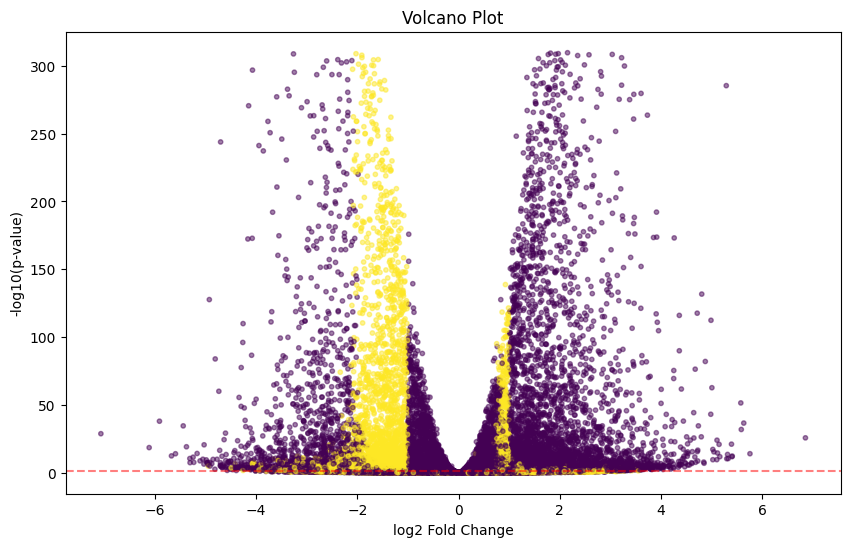

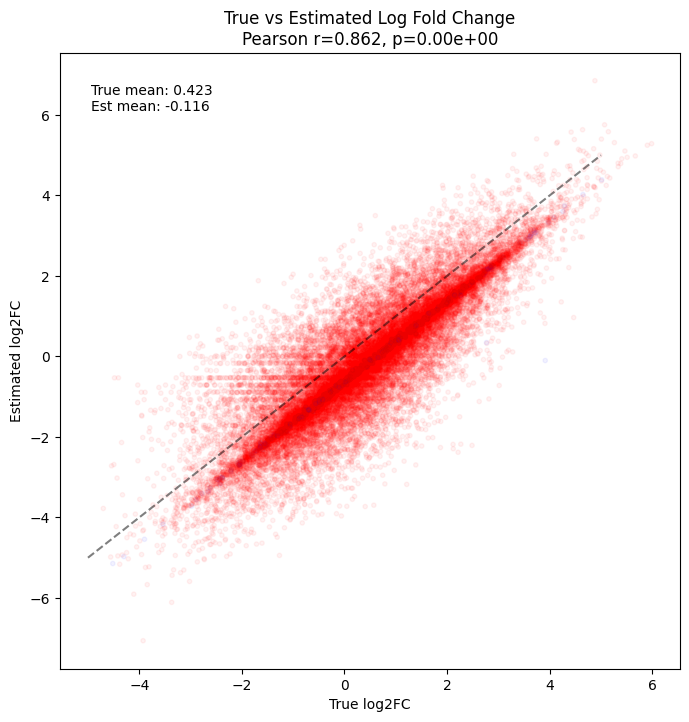

False Positives: 3366, False Negatives: 3943
True Positives: 6064, True Negatives: 16627

True size factors mean: 1.916
Estimated size factors mean: 1.786


In [3]:
from scipy.stats import pearsonr

# Convert torch data to pandas DataFrame - samples as rows, genes as columns
counts_df = pd.DataFrame(
    counts_observed.numpy().astype(int),
    columns=[f"gene_{i}" for i in range(gene_size)]
)

# Create metadata - one row per sample
metadata = pd.DataFrame({
    'condition': ['base']*group_size + ['upreg']*group_size
}, index=[f"sample_{i}" for i in range(group_size*2)])

# Run PyDESeq2
dds = DeseqDataSet(counts=counts_df, metadata=metadata, design_factors='condition')
dds.deseq2()

# Get results
stat_res = DeseqStats(dds, contrast=['condition', 'upreg', 'base'])
stat_res.summary()
results = stat_res.results_df

# Extract outputs
# Extract outputs
estimated_size_factors = dds.obs['size_factors'].values
estimated_lfc = results['log2FoldChange'].values
padj = results['padj'].values

# Calculate false positives/negatives
true_positive = (np.abs(log_fc_true) > 1).numpy()
predicted_positive = ((padj < 0.05) & (np.abs(estimated_lfc)>1) )

FP = (predicted_positive & ~true_positive)
FN = (~predicted_positive & true_positive)
TP = (predicted_positive & true_positive)
TN = (~predicted_positive & ~true_positive)

# Volcano plot
plt.figure(figsize=(10,6))

plt.scatter(results['log2FoldChange'], -np.log10(results['pvalue']), 
            c=[color for color in FP|FN], alpha=0.5, s=10)
plt.axhline(-np.log10(0.05), color='red', linestyle='--', alpha=0.5)
plt.xlabel('log2 Fold Change')
plt.ylabel('-log10(p-value)')
plt.title('Volcano Plot')
plt.show()

# True vs Estimated upregulation
true_lfc = log_fc_true.numpy() / np.log(2)

# Filter out NaN values for correlation
valid_mask = ~np.isnan(estimated_lfc)
corr, pval = pearsonr(true_lfc[valid_mask], estimated_lfc[valid_mask])

# Calculate mean upregulation/downregulation
true_mean = np.mean(true_lfc)
est_mean = np.mean(estimated_lfc[valid_mask])

# Color by log base mean (red if log_base_means < 0, i.e., mean count < 1)
colors = ['red' if lbm < 10 else 'blue' for lbm in log_base_means.numpy()]

plt.figure(figsize=(8,8))
plt.scatter(true_lfc, estimated_lfc, alpha=0.05, s=10, c=colors)
plt.plot([-5,5], [-5,5], 'k--', alpha=0.5)
plt.xlabel('True log2FC')
plt.ylabel('Estimated log2FC')
plt.title(f'True vs Estimated Log Fold Change\nPearson r={corr:.3f}, p={pval:.2e}')
plt.text(0.05, 0.95, f'True mean: {true_mean:.3f}\nEst mean: {est_mean:.3f}', 
         transform=plt.gca().transAxes, verticalalignment='top')
plt.show()


FP = np.sum(predicted_positive & ~true_positive)
FN = np.sum(~predicted_positive & true_positive)
TP = np.sum(predicted_positive & true_positive)
TN = np.sum(~predicted_positive & ~true_positive)
print(f"False Positives: {FP}, False Negatives: {FN}")
print(f"True Positives: {TP}, True Negatives: {TN}")
print(f"\nTrue size factors mean: {size_factors.mean():.3f}")
print(f"Estimated size factors mean: {estimated_size_factors.mean():.3f}")


In [4]:
# Convert log2 to natural log and calculate mean error
np.nanmean(log_fc_true.detach().numpy()-(estimated_lfc* np.log(2)))

np.float64(0.38174510410685414)

-0.20675309316093585


/Users/rowancallahan/Projects/global_upreg_seq/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


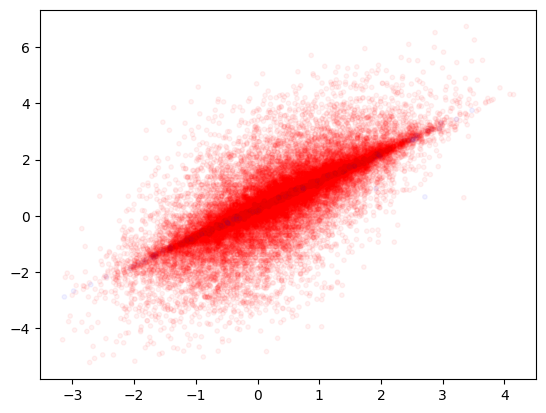

In [5]:
counts_df = pd.DataFrame(
    counts_observed.numpy().astype(int),
    columns=[f"gene_{i}" for i in range(gene_size)]
)

estimated_logfc_ttest = -np.log(counts_df[0:group_size].mean()) +np.log(counts_df[group_size:].mean())

plt.scatter(log_fc_true.numpy(), estimated_logfc_ttest, alpha=0.05, s=10, c=colors)

fc_list = log_fc_true.numpy()- estimated_logfc_ttest
valid =  np.isfinite(fc_list)
result = np.mean(fc_list[valid])
print(result)

#after hand checking with code written by claude the false positives and the false negatives
#appear to be better with our method than with the t test method even after multiple testing correction
#we still get twice as many false positives 1000 with 9000 false negatives,
#  whereas the bayesian model has 500 false negatives and 8000 false negatives, so half as many false positives
#should maybe use a normalizing flow for the bayesian model

In [6]:
print("hello")

hello


In [7]:
import torch
from pyro.nn import PyroModule
class factor_model_nb_nosf(PyroModule):
    def forward(self, x, y, classnum=2):
        N, P = x.shape

        loading_plate = pyro.plate("loading_plate", P, dim=-1)
        factor_plate = pyro.plate("factor_plate", classnum-1, dim=-2)
        
        alpha_1 = pyro.sample("alpha_1", dist.HalfNormal(5))
        with loading_plate:
            log_mu0 = pyro.sample("log_mu0", dist.Normal(5,10))
            alpha_0_inv = pyro.sample("alpha_0", dist.HalfNormal(5))

        with factor_plate:
            tau_g = pyro.sample("tau_g", dist.HalfCauchy(2.0))
            with loading_plate:
                tau_l = pyro.sample("tau_l", dist.HalfCauchy(2.0))
                log_fc = pyro.sample("log_fc", dist.Normal(0, 1.0 * tau_g * tau_l))


        with pyro.plate("data", N, dim=-2):
            with loading_plate:
                log_mu = (log_mu0).clamp(min=-4., max=18.) + (log_fc.unsqueeze(0) * y.unsqueeze(-1))
                log_mu = log_mu.squeeze()
                log_mu = torch.clamp(log_mu, min = torch.tensor(-6.0), max=torch.tensor(20.))

                alpha_inv = pyro.deterministic("alpha_inv",  1/((alpha_1/(torch.exp(log_mu)+1)) +1/alpha_0_inv))#.clamp(min=1e-6,max=1e10)
                logits = (log_mu - torch.log(alpha_inv))#.clamp(min=-20, max=20)

                pyro.sample("obs", dist.NegativeBinomial(total_count=alpha_inv, logits=logits), obs=x)

In [8]:
import torch
from pyro.nn import PyroModule
class factor_model_nb_nosf(PyroModule):
    def forward(self, x, y, classnum=2):
        N, P = x.shape

        loading_plate = pyro.plate("loading_plate", P, dim=-1)
        factor_plate = pyro.plate("factor_plate", classnum-1, dim=-2)

        #log_global_alpha= pyro.sample("log_global_alpha", dist.Normal(0,3)) 
        with loading_plate:
            log_mu0 = pyro.sample("log_mu0", dist.Normal(5,10))
            alpha_gene = pyro.sample("alpha_gene", dist.LogNormal(-2.0,2.5))
            #alpha_gene_inv = pyro.sample("alpha_gene", dist.HalfNormal(5)) 
        with factor_plate:
            #tau_g = pyro.sample("tau_g", dist.HalfCauchy(3.0))
            tau_g = pyro.sample("tau_g", dist.HalfNormal(3.0))

            with loading_plate:
                #tau_l = pyro.sample("tau_l", dist.HalfCauchy(3.0))
                tau_l = pyro.sample("tau_l", dist.HalfNormal(3.0))

                log_fc = pyro.sample("log_fc", dist.Normal(0, 1.0 * tau_g * tau_l))
                #log_fc = pyro.sample("log_fc", dist.Laplace(0, 1.0))


        with pyro.plate("data", N, dim=-2):
            size_factor_square = pyro.sample("sample_alpha", dist.LogNormal(-1,2))
            #size_factor_square = pyro.param("sample_alpha", torch.ones(N,1),
            #                                constraint=pyro.distributions.constraints.greater_than(1.))

            #log_size_factor_square= pyro.sample("sample_alpha", dist.Normal(0,2))
            #size_factor_square_raw = pyro.sample("sample_alpha_raw", dist.HalfNormal(0,2))
            #size_factor_square = pyro.deterministic("sample_alpha", torch.exp(size_factor_square_raw-1))


            with loading_plate:
                log_mu = (log_mu0).clamp(min=-4.0, max=18.0) + (log_fc.unsqueeze(0) * y.unsqueeze(-1))
                log_mu = log_mu.squeeze()
                log_mu = torch.clamp(log_mu, min = torch.tensor(-7.0), max=torch.tensor(18.))

                alpha_inv = pyro.deterministic("alpha_inv", torch.clamp(1/(
                    ((size_factor_square) * alpha_gene).clamp(max=300.0) +
                    (size_factor_square-2.0*torch.sqrt(size_factor_square) +1.0).clamp(min=0.0)+
                    ( (torch.sqrt(size_factor_square) -1.0)/(20.0+torch.exp(log_mu)) ).clamp(min=-100.0)
                    #(torch.sqrt(size_factor_square) -1 + 1/(10.0+torch.exp(log_mu))) *(torch.sqrt(size_factor_square)-1)
                ),min=1e-4, max=1e4))

                logits = (log_mu - torch.log(alpha_inv)).clamp(min=-15, max=18)
                if torch.isinf(logits).any() or torch.isinf(alpha_inv).any():
                    print(f"Inf detected: logits range [{logits.min()}, {logits.max()}]")
                    print(f"alpha_inv range [{alpha_inv.min()}, {alpha_inv.max()}]")
                pyro.sample("obs", dist.NegativeBinomial(total_count=alpha_inv, logits=logits), obs=x)

In [9]:
#previous alpha inverse
               # alpha_inv = pyro.deterministic("alpha_inv",torch.clamp(1/(
               # (1/(alpha_gene_inv)) - 
               # (alpha_sample-1)/(alpha_sample*torch.exp(log_mu)) # the times ten is alpha 0
               # ),min=1e-15)
               # )

In [10]:
#counts_observed_new = counts_observed.detach()[:,counts_observed.mean(0)>0.5]
from pyro.optim import ClippedAdam
from pyro.infer.autoguide import AutoGuideList, AutoDelta, AutoDiagonalNormal
from pyro import poutine

pyro.clear_param_store()
model = factor_model_nb_nosf()
pyro.enable_validation(False)
#set the mean log mu0 to be half normal with an offset to allow it to be small
#guide = pyro.infer.autoguide.AutoDiagonalNormal(model)
guide = AutoGuideList(model)
guide.append(AutoDiagonalNormal(poutine.block(model, hide=["sample_alpha"])))
guide.append(AutoDelta(poutine.block(model, expose=["sample_alpha"])))
iterations = 900
optim=  ClippedAdam({"lr": 0.1, "clip_norm": 100.0, "lrd":0.0005**(1/iterations)})
model, guide, (losses, logp) = global_upreg_seq.train(counts_observed,labels, model,num_iterations= iterations,optim=optim)

Loss: 4.506e+06: 100%|██████████| 900/900 [00:55<00:00, 16.16it/s]


In [406]:
#pyro.render_model(model, model_args=(counts_observed,labels))

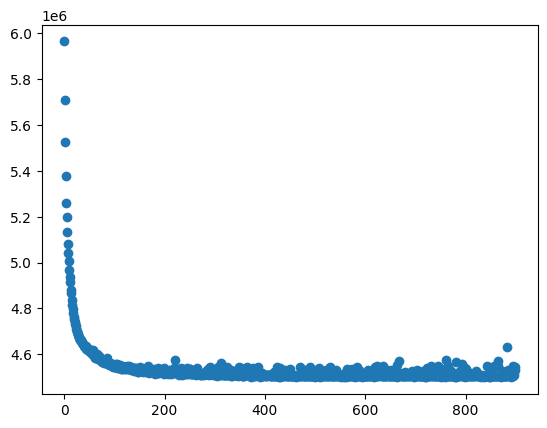

In [11]:
#TODO need to make a figure to test whether things are converging
plt.scatter(np.arange(0,iterations,1), (torch.tensor(losses)))

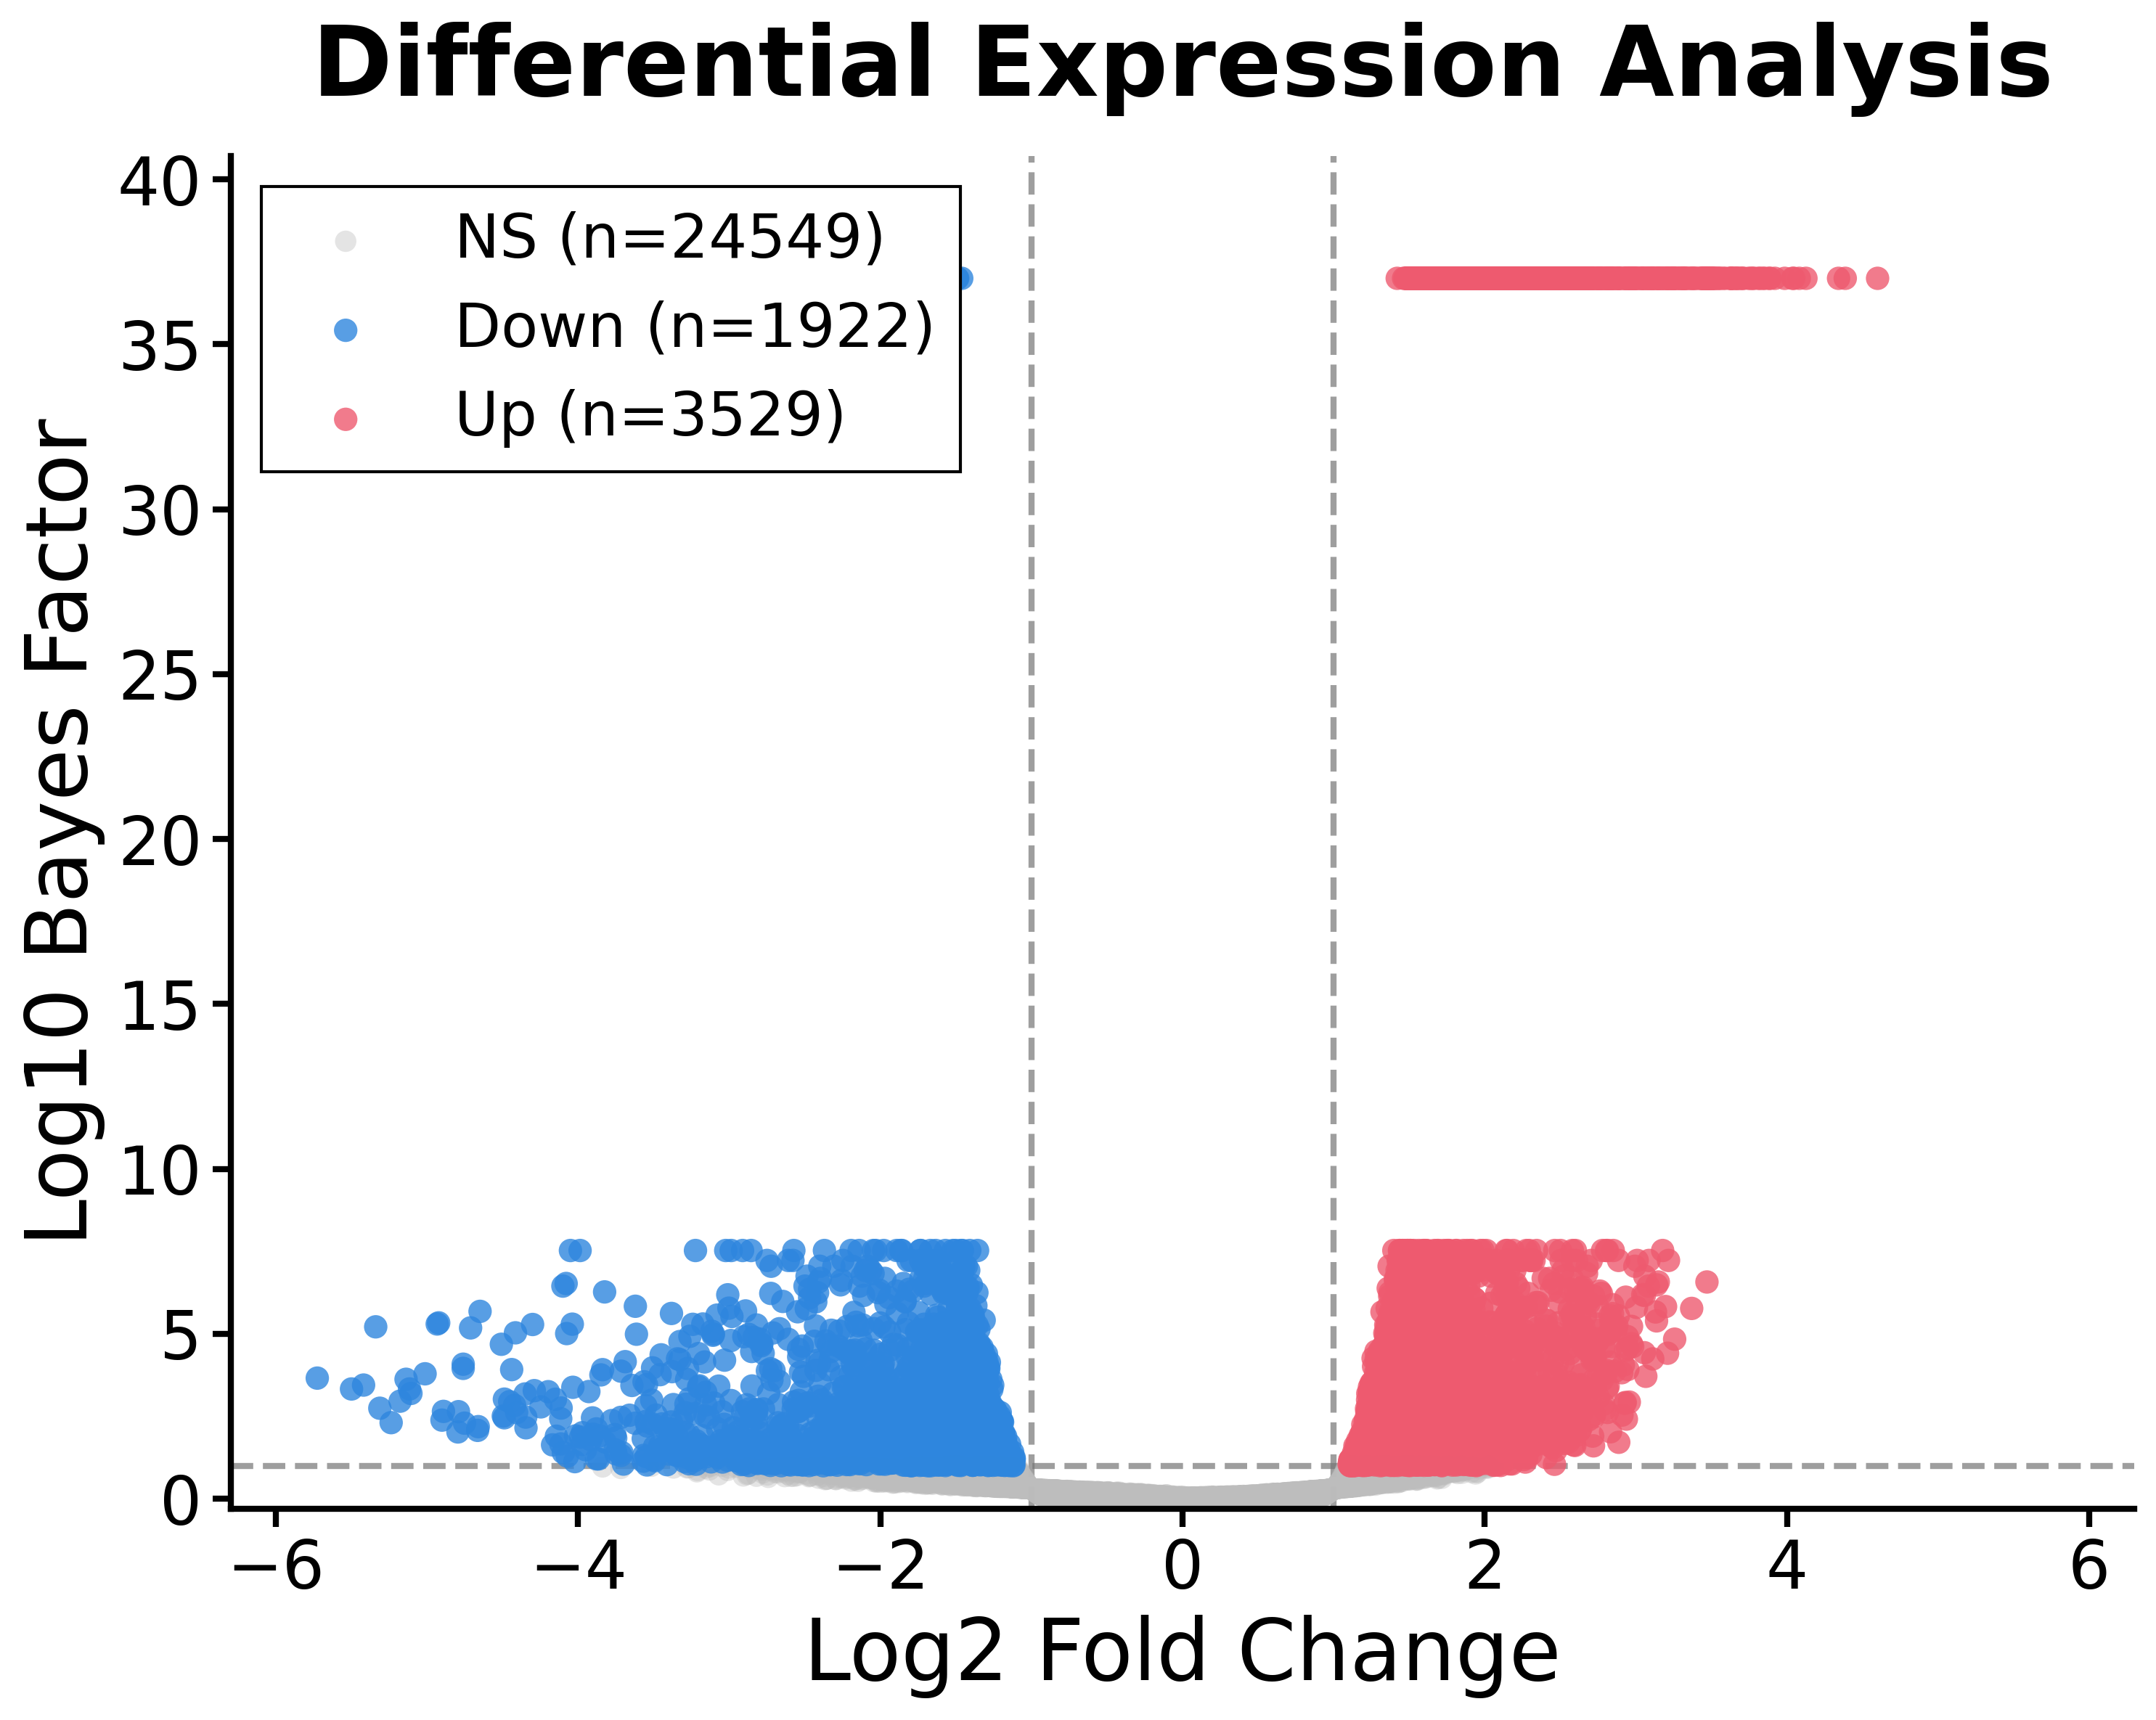

In [12]:
import global_upreg_seq
log10_bf, log_fc,fig,ax = global_upreg_seq.calculate_foldchange_bf(guide,1.0, non_bf=True)

In [13]:
# Classify based on BF threshold
likelihood_threshold = 1.0 # or another value
bf_significant = log10_bf > likelihood_threshold

# True differential expression
truly_diff = np.abs(log_fc_true.numpy()) > 1

# Confusion matrix
tp = np.sum(bf_significant & truly_diff)
fp = np.sum(bf_significant & ~truly_diff)
fn = np.sum(~bf_significant & truly_diff)
tn = np.sum(~bf_significant & ~truly_diff)

print(f"FP: {fp}, FN: {fn}")
print(f"FPR: {fp/(fp+tn):.3f}, FNR: {fn/(fn+tp):.3f}")
print(f"TP: {tp}, TN: {tn}")

FP: 803, FN: 5359
FPR: 0.040, FNR: 0.536
TP: 4648, TN: 19190


In [14]:
from pyro.infer import Predictive

# Sample from the guide (variational posterior)
predictive = Predictive(model, guide=guide, num_samples=500)
samples = predictive(counts_observed, labels)

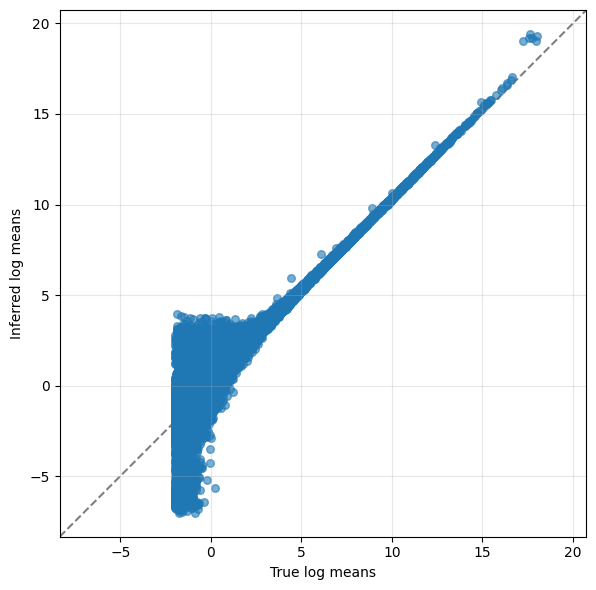

In [15]:
log_mu0 = samples["log_mu0"].mean(0)  # [P]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(log_base_means, log_mu0, alpha=0.6, s=30)#, c=colors)

# Add y=x reference line
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),
    np.max([ax.get_xlim(), ax.get_ylim()]),
]
ax.plot(lims, lims, 'k--', alpha=0.5, zorder=0)

ax.set_aspect('equal')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('True log means')
ax.set_ylabel('Inferred log means')
ax.grid(True, alpha=0.3)
plt.tight_layout()

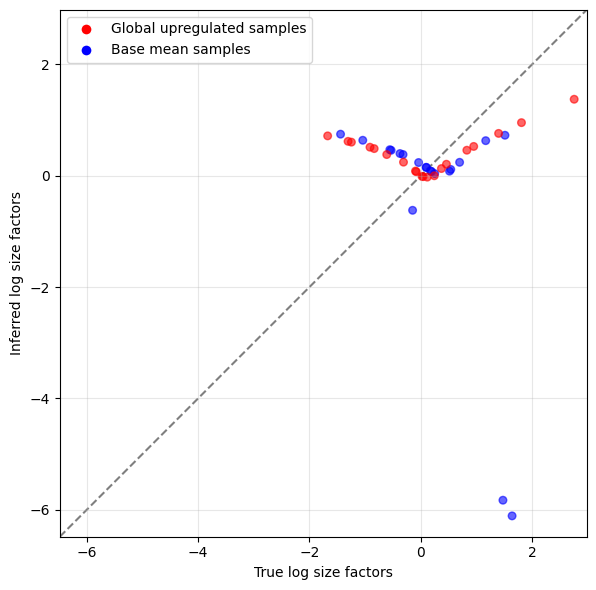

In [16]:
log_size_factor = (samples["sample_alpha"].mean(0))  # [N]

fig, ax = plt.subplots(figsize=(8, 6))

# Color based on y value
colors = ['red' if yi == 1 else 'blue' for yi in labels]
ax.scatter(torch.log(size_factors), torch.log(torch.sqrt(log_size_factor)), alpha=0.6, s=30, c=colors)

# Add legend
red_patch = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', 
                       markersize=8, label='Global upregulated samples')
blue_patch = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', 
                        markersize=8, label='Base mean samples')
ax.legend(handles=[red_patch, blue_patch])

# Add y=x reference line
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),
    np.max([ax.get_xlim(), ax.get_ylim()]),
]
ax.plot(lims, lims, 'k--', alpha=0.5, zorder=0)

ax.set_aspect('equal')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('True log size factors')
ax.set_ylabel('Inferred log size factors')
ax.grid(True, alpha=0.3)
plt.tight_layout()

tensor(-0.2161)

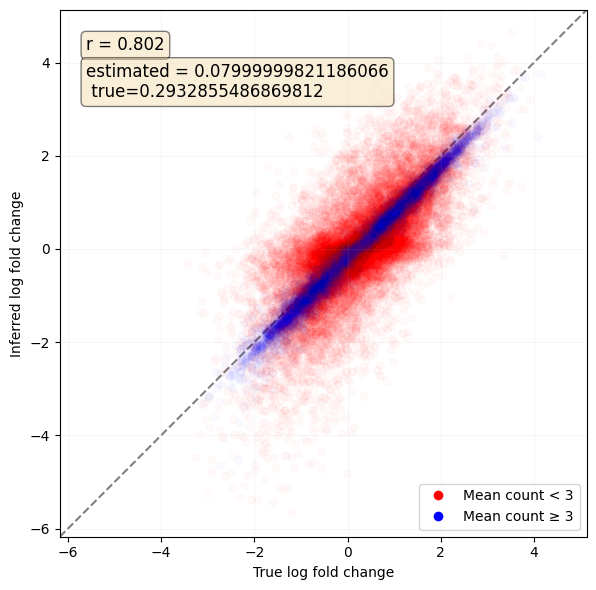

In [17]:
# Compare the log fc
estimated_log_fc = samples["log_fc"].mean(0)
fig, ax = plt.subplots(figsize=(8, 6))

# Color based on mean count < 1 (assuming log_base_means exists)
colors = ['red' if torch.exp(lm) < 10 else 'blue' for lm in log_base_means]
ax.scatter(log_fc_true.flatten(), estimated_log_fc.flatten(), alpha=0.02, s=30, c=colors)

# Calculate Pearson correlation
from scipy.stats import pearsonr
r, p_value = pearsonr(log_fc_true.flatten().detach().numpy(), 
                       estimated_log_fc.flatten().detach().numpy())

# Add correlation as text
ax.text(0.05, 0.95, f'r = {r:.3f}', transform=ax.transAxes, 
        fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.text(0.05, 0.9,
        f'estimated = {torch.mean(estimated_log_fc*100.).round()/100.}\n true={log_fc_true.mean()}',
        transform=ax.transAxes, 
        fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Add legend
red_patch = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', 
                       markersize=8, label='Mean count < 3')
blue_patch = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', 
                        markersize=8, label='Mean count ≥ 3')
ax.legend(handles=[red_patch, blue_patch])

# Add y=x reference line
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),
    np.max([ax.get_xlim(), ax.get_ylim()]),
]
ax.plot(lims, lims, 'k--', alpha=0.5, zorder=0)

ax.set_aspect('equal')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('True log fold change')
ax.set_ylabel('Inferred log fold change')
ax.grid(True, alpha=0.1)
plt.tight_layout()


torch.mean(estimated_log_fc - log_fc_true)

tensor(0.0014)


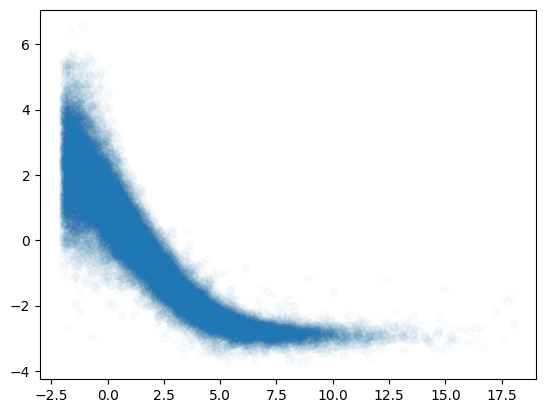

In [18]:
import matplotlib.pyplot as plt
alpha_gene = (samples["alpha_gene"].mean(0))  # [N]
#plt.hist(np.log(alpha_gene), bins=30)
#plt.show()
print(1.0/torch.max(alpha_gene))
1.0/torch.min(alpha_gene)

plt.scatter(log_base_means, torch.log(alpha_gene).detach().cpu().numpy(), alpha=0.02, s=30)#, c=colors)
plt.show()
